# PyTorch Computer Vision

* Computer Vision Reference: https://www.learnpytorch.io/03_pytorch_computer_vision/

## 1.Computer vision libraries
* [`torchvision`](https://docs.pytorch.org/vision/stable/index.html)
* `torchvision.datasets` - get datasetds and data loading function for computer vision
* `torchvision.models` - get pretrained computer vision models
* `torchvision.transforms` - functions for manipulating a vision data (images) to be suitable fo use with an ML model
* `torch.utils.data.Dataset` - Base dataset class for PyTorch
* `torch.utils.data.DataLoader` - Creates a Python iterable over a dataset

In [ ]:
# Import PyTorch
import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

# Import matplotlib for displaying data
import matplotlib.pyplot as plt
import numpy as np

# Check versions
print(torch.__version__)
print(torchvision.__version__)

2.10.0+cu128
0.25.0+cu128


## 2.Getting a dataset
*The dataset we will be using is `FashionMNIST`* from torchvision.datasets

In [ ]:
# Setup training data
train_data = datasets.FashionMNIST(
    root="data", # where to download data to
    train=True, # get training data
    download=True, # download data if it doesn't exist on disk
    transform=torchvision.transforms.ToTensor(), # images come as PIL format, we want to turn into torch tensors
    target_transform=None # how do we want ot tranform the labels/targets
)

test_data = datasets.FashionMNIST(
    root = "data",
    train= False,
    download = True,
    transform = ToTensor(),
    target_transform = None,
)

len(train_data), len(test_data)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.89MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.3MB/s]


(60000, 10000)

In [ ]:
# See the first training example
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [ ]:
class_names = train_data.classes
class_names


['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

### 2.1 Check input and output shapes of data

In [ ]:
# Check the shape of our image
print(f"Image shape: {image.shape} -> [color_channels, height, width]")
print(f"Image label:  {class_names[label]}")

Image shape: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Image label:  Ankle boot


### 2.2 Visualizing the data

Image shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

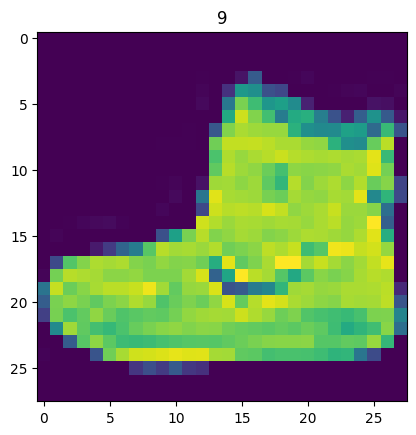

In [ ]:
image, label = train_data[0]
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze())
plt.title(label)



(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

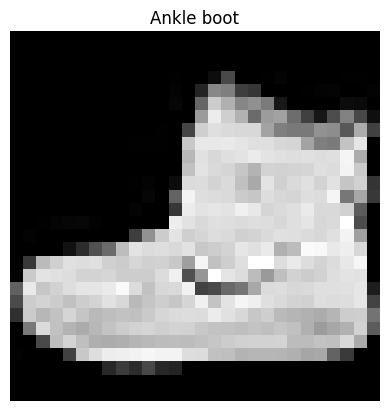

In [ ]:
plt.imshow(image.squeeze(),cmap="gray")
plt.title(class_names[label])
plt.axis(False)

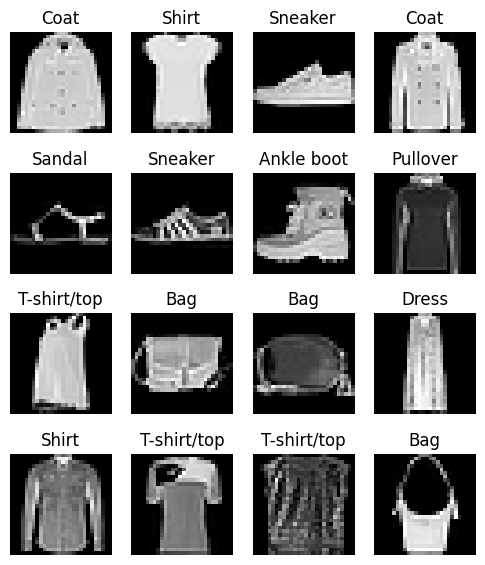

In [ ]:
# Plot more images
# torch.manual_seed(42)
fig = plt.figure(figsize=(6,7))
rows,cols = 4,4
for i in range(1, rows*cols+1):
  random_idx = torch.randint(0, len(train_data), size=[1]).item()
  img, label = train_data[random_idx]
  fig.add_subplot(rows,cols,i)
  plt.imshow(img.squeeze(), cmap="gray")
  plt.title(class_names[label])
  plt.axis(False)


## 2.Prepare DataLoader
*Now our data is in the form of PyTorch Datasets.
DataLoader turn our datasets into Pyhton iterable*
More specifically, we want to turn our data into ***batches*** or ***minibatches***
1. It is more computationally efficient, as in, your computing hardware may not be able to look (store in memory) at 60000 images in one hit. So we break it down to 32 images at a time (batch size of 32)
2. It gives out NN more chances to update its gradients into epochs

[***Mini Batch***](https://www.youtube.com/watch?v=4qJaSmvhxi8)



In [ ]:
from torch.utils.data import DataLoader

# Setup the batch size hyperparameter
BATCH_SIZE = 32

# Turn datasets into iterables
train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False) ## The oreder doesnt matter in testing

train_dataloader, test_dataloader




(<torch.utils.data.dataloader.DataLoader at 0x7e90d9b13d70>,
 <torch.utils.data.dataloader.DataLoader at 0x7e90da8cf3b0>)

In [ ]:
# Check out what've created
print(f"DataLoaders: {train_dataloader, test_dataloader}")
print(f"Length of train_dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test_dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

DataLoaders: (<torch.utils.data.dataloader.DataLoader object at 0x7e90d9b13d70>, <torch.utils.data.dataloader.DataLoader object at 0x7e90da8cf3b0>)
Length of train_dataloader: 1875 batches of 32
Length of test_dataloader: 313 batches of 32


In [ ]:
# Check out what is inside the training dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size : torch.Size([1, 28, 28])
Label : 2, label size: torch.Size([])


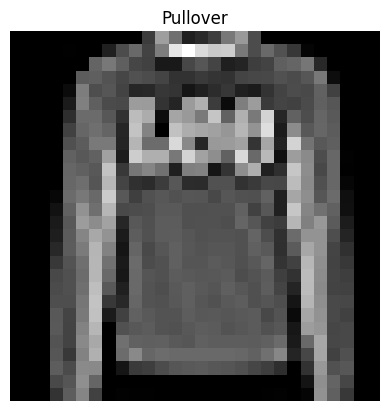

In [ ]:
# Show a sample
# torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]

plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis("off")
print(f"Image size : {img.shape}")
print(f"Label : {label}, label size: {label.shape}")

## 3.Model 0: Build a baseline model
*When starting to build a series of machine learning modelling experiments, it's best to practice to start with a baseline model*

A baseline model is a simple  model you will try to improve upon with subsequent models/experiments.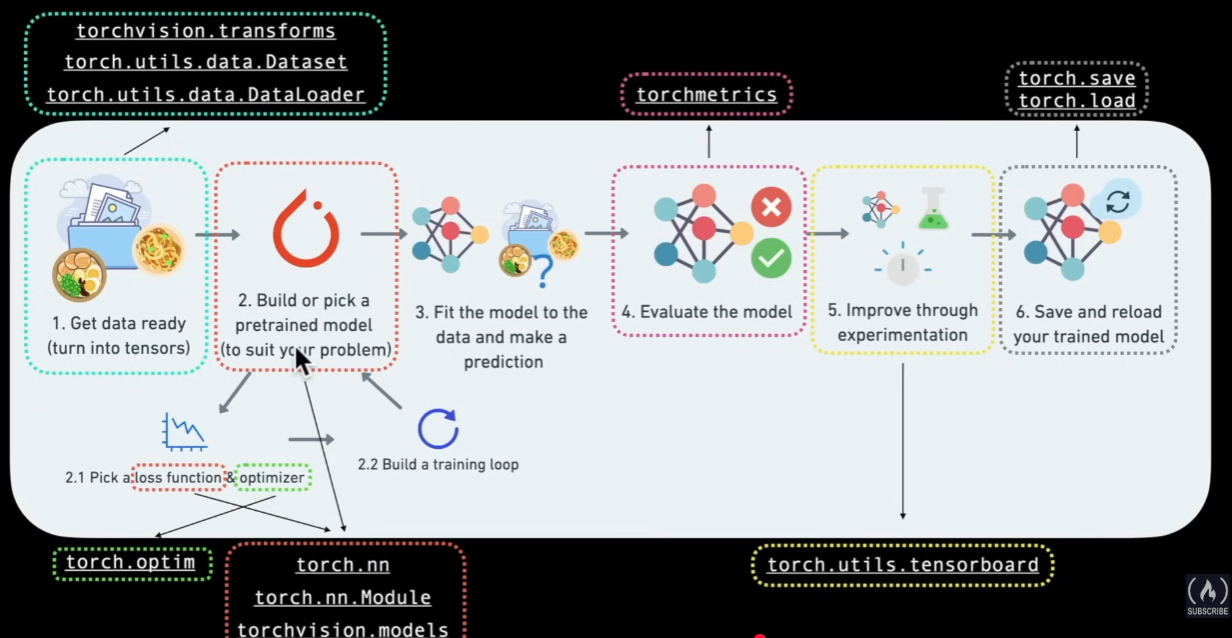

In other words: start simply and add complexity when necessary

Create a flatten layer

In [ ]:
from torch._higher_order_ops.invoke_subgraph import OutputMetadata
# Create a flatten layer we want the data in vector because we work with base model  and Linear functions
flatten_model= nn.Flatten()

#Get a single sample
x = train_features_batch[0]
x.shape

#Flatten the sample
output = flatten_model(x) # perform forward pass

# Print out what's happened
print(f"Shape before flattening: {x.shape}  -> [color_channels, height, width]")
print(f"Shape after flattening: {output.shape} -> [color_channels, height * width]")\

output

Shape before flattening: torch.Size([1, 28, 28])  -> [color_channels, height, width]
Shape after flattening: torch.Size([1, 784]) -> [color_channels, height * width]


tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [ ]:
from torch import nn

class FashionMNISTModelV0(nn.Module):
  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,
                  out_features=hidden_units),
        nn.Linear(in_features=hidden_units, ## Input in Sequantial in Layer 2 should be equal to output of Layer 1
                  out_features=output_shape)
    )

  def forward(self,x):
    return self.layer_stack(x)


In [ ]:
# Create an instance of the model

torch.manual_seed(42)

model_0 = FashionMNISTModelV0(input_shape=784,# 28*28
                              hidden_units=10,# how many units in input layer
                              output_shape=len(class_names))# one for every class
model_0.to("cpu")

model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [ ]:
dummy_x = torch.rand([1,1,28,28])

model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

## 4.Train the Model



***Setup loss, optimizer and evalutaion metrics***
* Loss function - since we're working with multi-class data, our loss function will be `nn.CrossEntropyLoss()`
* Optimizer - our optimizer `torch.optim.SGD()` stochastic gradient descent
* Evaluation metricx- since we're working on a classification problem, let's use accuracy as our evaluation metric

In [ ]:
import requests
from pathlib import Path

# Download helper function from Learn PyTorch repo
if Path("helper_function.py").is_file():
  print("helper_function.py already exists, skipping download")
else:
  print("Downloading helper_function.py..")
  request = requests.get(url="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_function.py", "wb") as f:
    f.write(request.content)

In [ ]:
# Import accuracy metric
from helper_function import accuracy_fn

# Setup loss function and an optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.1)

***Creating a function to time our experiments***

Two of the main things we will want to track are:
1. Model's perforamnce
2. How fast it runs

In [ ]:
from timeit import default_timer as timer

def print_train_time(start: float,
                    end: float,
                    device: torch.device = None):
  """Print deifference between start and end time"""
  total_time = end - start
  print(f"Train time on {device}: {total_time:.3f} seconds")

  return total_time

In [ ]:
start_time = timer()
end_time = timer()

print_train_time(start=start_time,end=end_time,device="cpu")



Train time on cpu: 0.000 seconds


2.924999989772914e-05

### 4.1 Creating a training loop and training a model on batches of data

1. Loop through epochs
2. Loop through training batches, performs training steps, calculate the train loss *per batch*
3. Loop through testing batches, perform testing steps, calculate the test loss *per batch*
4. Print down what's happening
5. Time it all `for fun`

In [ ]:
from numpy.matrixlib import test
# Import tqdm for progress bar
from tqdm.auto import tqdm

# Set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# Set the number of epochs (small for faster training time)
epochs = 3

# Loop through the epochs
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch} \n------")
  ### Training
  train_loss = 0

  # Loop through the training batches
  for batch, (X,y) in enumerate(train_dataloader):
    model_0.train()

    # 1. Forward pass
    y_pred = model_0(X)

    # 2. Calculate the loss
    loss = loss_fn(y_pred,y)
    train_loss += loss # Accumulate the training batch loss

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

  # Print out what's happening
    if batch % 400 == 0:
      print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples.")

  # Divide total train loss by length of train loader
  train_loss /= len(train_dataloader)

    ### Testing
  test_loss, test_acc = 0, 0
  model_0.eval()

  with torch.inference_mode():
    for X_test,y_test in test_dataloader: # X - features, y - images
    # 1.Forward pass
      test_pred = model_0(X_test)

    # 2.Calculate the loss
      test_loss += loss_fn(test_pred,y_test)

    # 3.Calculate accuracy
      test_acc += accuracy_fn(y_true = y_test, y_pred= test_pred.argmax(dim=1)) # Call argmax because logits need to be transformed

  # Calculate the test loss average per batch
    test_loss /= len(test_dataloader)

  # Calculate the test acc average per batch
    test_acc /= len(test_dataloader)

  # Print out what's happening
  print(f"\nTrain loss: {train_loss:.4f} | Test loss: {test_loss:.4f} Test acc: {test_acc}")

  # Calculate the training time
  train_time_end_on_cpu = timer()
  total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu,
                                      end=train_time_end_on_cpu,
                                      device=str(next(model_0.parameters()).device))


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0 
------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

Train loss: 0.5904 | Test loss: 0.5095 Test acc: 82.03873801916933
Train time on cpu: 9.567 seconds
Epoch: 1 
------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

Train loss: 0.4763 | Test loss: 0.4799 Test acc: 83.19688498402556
Train time on cpu: 19.050 seconds
Epoch: 2 
------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

Train loss: 0.4550 | Test loss: 0.4766 Test acc: 83.42651757188499
Train time on cpu: 27.961 seconds


In [ ]:
next(model_0.parameters()).device

device(type='cpu')

### 4.2 Functionalizing testing and training loops

In [ ]:
def train_step(model:torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn:torch.nn.Module,
              optimizer:torch.optim.Optimizer,
              accuracy_fn,
              device: torch.device):
  # Training
  train_loss,train_acc =0,0

  # Put data into training mode
  model.train()

  # Loop through the training batches
  for batch, (X,y) in enumerate(data_loader):
    #Put data on target device
    X,y = X.to(device), y.to(device)

    # 1. Forward pass
    y_pred = model(X)

    # 2. Calculate the loss and acc (per batch)
    loss = loss_fn(y_pred,y)
    train_loss += loss # Accumulate the training batch loss
    train_acc += accuracy_fn(y_true = y,
                             y_pred= y_pred.argmax(dim=1)) # go from logits -> prediction labels

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

  # Divide total train loss and acc by length of train loader
  train_loss /= len(data_loader)
  train_acc /= len(data_loader)

  print(f"Train loss: {train_loss:.5f} | Train acc: {train_acc:.2f}")

  return train_loss, train_acc

In [ ]:
def test_step(model:torch.nn.Module,
              data_loader:torch.utils.data.DataLoader,
              loss_fn:torch.nn.Module,
              accuracy_fn,
              device: torch.device = None):
  test_loss, test_acc = 0, 0

  # Put the model in eval mode
  model.eval()

  # Turn on inference mode
  with torch.inference_mode():
    for X,y in data_loader:
      # Put data on target device
      X,y = X.to(device), y.to(device)

      # 1. Forward pass (outputs raw logits)
      test_pred = model(X)

      # 2. Calc the loss
      test_loss += loss_fn(test_pred,y).item()

      # 3. Calc the acc
      test_acc += accuracy_fn(y_true=y,
                              y_pred=test_pred.argmax(dim=1))

  # Adjust metrics and print out
  test_loss /= len(data_loader)
  test_acc /= len(data_loader)

  print(f"Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}")

### 4.3 Make predicitions and get Model 0 results

In [ ]:
torch.manual_seed(42)

def eval_model(model:torch.nn.Module,
                data_loader: torch.utils.data.DataLoader,
                loss_fn: torch.nn.Module,
                accuracy_fn,
                device: torch.device):

  """Returns a dictionary containing the results of model prediction on data_loader."""
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X,y in tqdm(data_loader):
    # Put data on target device
      X, y = X.to(device), y.to(device)

    # Make predictions
      y_pred = model(X)

      # Accumulate the loss and acc values per batch
      loss += loss_fn(y_pred,y)
      acc += accuracy_fn(y_true=y,
                        y_pred=y_pred.argmax(dim=1))

    # Scale loss and acc to find the average loss/acc pre batch
    loss /= len(data_loader)
    acc /= len(data_loader)

    return{"model_name": model.__class__.__name__,# Only works when model was created with a class name
            "model_loss": loss.item(),
            "model_acc": acc}

## 5.Setup device agnositic-code (for using a GPU if there is one)

In [ ]:
!nvidia-smi

Mon Apr 20 11:31:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
device = torch.device("cuda") if torch.cuda.is_available() else "cpu"
device

device(type='cuda')

## 6.Build a better model with non-linearity

In [ ]:
# Create a model with linear and non-linear layers
class FashionMNISTModelV1(nn.Module):
  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape:int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,
                  out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,
                  out_features=output_shape)
    )

  def forward(self,x: torch.Tensor):
    return self.layer_stack(x)

In [ ]:
# Create an instance of model_1
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape=784,
                              hidden_units=10,
                              output_shape=len(class_names)).to(device)
model_1

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
  )
)

### 6.1 raining and testing `model 1`

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Measure time
from timeit import default_timer as timer

train_time_start_model_1 = timer()

# Train and test the model
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-------")
  train_step(model=model_1.to(device=device),
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device =device)

  test_step(model=model_1,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device)

  train_time_end_model_1 = timer()

  total_train_time_model_1 = print_train_time(start=train_time_start_model_1,
                                              end=train_time_end_model_1,
                                              device=device)




  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Train loss: 2.31011 | Train acc: 11.31
Test loss: 2.31077 | Test acc: 10.75
Train time on cuda: 15.279 seconds
Epoch: 1
-------
Train loss: 2.31011 | Train acc: 11.31
Test loss: 2.31077 | Test acc: 10.75
Train time on cuda: 24.834 seconds
Epoch: 2
-------
Train loss: 2.31011 | Train acc: 11.31
Test loss: 2.31077 | Test acc: 10.75
Train time on cuda: 35.795 seconds


### 6.2 Evaluating model 1

In [ ]:
model_1_results = eval_model(
                            model=model_1,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn,
                             device=device
                             )
model_1_results

total_train_time_model_1 = print_train_time(start=train_time_start_model_1,
                                            end=train_time_end_model_1,
                                            device=device)

  0%|          | 0/313 [00:00<?, ?it/s]

Train time on cuda: 35.795 seconds


## 7.Model 2: Building a Convolutional Neural Network (CNN)
 * CNN's are also known ConvNets.
 * CNN's are known for their capabilities to find patterns in visual data
 * [More About CNNs](https://poloclub.github.io/cnn-explainer/)

In [ ]:
import torch
# Create a convolutional neural network
class FashionMNISTModelV2(nn.Module):
  """Model architecture that replicates the TinyVGG model from CNN explainer website"""
  def __init__(self,input_shape: int,hidden_units: int, output_shape: int):
    super().__init__()

    self.conv_block_1= nn.Sequential(
        # Create a conv layer
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units,
                 out_channels=hidden_units,
                 kernel_size=3,
                 stride=1,
                 padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(), # The output of the upper 2 layers will be multidimensional sized and we have to faltten it (one vector)
        nn.Linear(in_features=hidden_units*7*7,
                  out_features=output_shape)
        )

  def forward(self,x):
      # Pass x through the layers
      x = self.conv_block_1(x)
      # print(f"Outputshape of conv_block 1: {x.shape}")
      x = self.conv_block_2(x)
      # print(f"Outputshape of conv_block 2: {x.shape}")
      x = self.classifier(x)
      return x

In [ ]:
# Make an instance of the CNN model
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1, # 1 color channel for black and white colored images/ Otherwise 3
                              hidden_units=10,
                              output_shape=len(class_names)).to(device)
model_2

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

### 7.1 Stepping through `nn.Conv2d`

[About Conv2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)

In [ ]:
torch.manual_seed(42)

# Create a batch of images
images=torch.randn(size=(32,3,64,64))
test_image = images[0]

print(f"Image batch shape: {images.shape}")
print(f"Single image shape: {test_image.shape}")
print(f"Test image: {test_image}")

Image batch shape: torch.Size([32, 3, 64, 64])
Single image shape: torch.Size([3, 64, 64])
Test image: tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
         [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.8563]],

        [[-0.

In [ ]:
torch_manual_seed = 42
# Create conv2d layer
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=3,
                       stride=1,
                       padding=0)

# Pass the data through the convolutional layer
conv_output = conv_layer(test_image)
conv_output.shape


torch.Size([10, 62, 62])

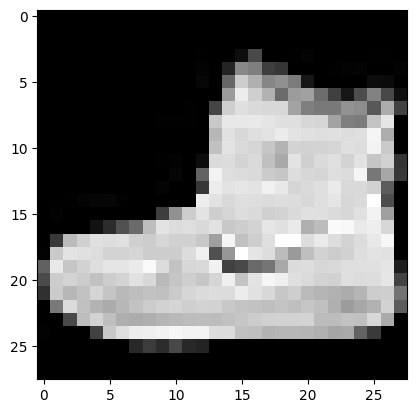

In [ ]:
plt.imshow(image.squeeze(), cmap="gray")

In [ ]:
rand_image_tensor = torch.rand(size=(1,28,28))
rand_image_tensor.shape

torch.Size([1, 28, 28])

In [ ]:
# Pass image through model
model_2(rand_image_tensor.unsqueeze(0).to(device))

tensor([[ 0.0342, -0.0697,  0.0616, -0.0407, -0.0062,  0.0199, -0.0023, -0.0113,
          0.0178,  0.0016]], device='cuda:0', grad_fn=<AddmmBackward0>)

### 7.2 Stepping through `nn.MaxPool2d`
[About MaxPool2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html)

In [ ]:
test_image.shape

torch.Size([3, 64, 64])

In [ ]:
# Print out original image shape
print(f"Test image original shape:{test_image.shape}")
print(f"Test image with unsqueezed dimension:{test_image.unsqueeze(0).shape}")

# Create a sample of nn.MaxPool2d layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# Pass data through just conv_layer
test_image_conv = conv_layer(test_image)
print(f"Shape after going through conv_layer(): {test_image_conv.shape}")

# Pass data through max_pool_layer
test_image_conv_and_max_pool = max_pool_layer(test_image_conv)
print(f"Shape after going through conv &  max_pool_layer(): {test_image_conv_and_max_pool.shape}")



Test image original shape:torch.Size([3, 64, 64])
Test image with unsqueezed dimension:torch.Size([1, 3, 64, 64])
Shape after going through conv_layer(): torch.Size([10, 62, 62])
Shape after going through conv &  max_pool_layer(): torch.Size([10, 31, 31])


In [ ]:
# Create a random tensor with a similar number of dimensions
torch.manual_seed(42)

random_tensor = torch.randn(size=(1,1,2,2))
print(f"Random tensor: \n {random_tensor}")
print(f"\nRandom tensor shape: \n{random_tensor.shape}")
# Create a max pool layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# Pass the random tensor through the max pooling layer
max_pool_tensor=max_pool_layer(random_tensor)
print(f"\nMax pool tensor: \n{max_pool_tensor}")
print(f"\nMax pool tensor shape: \n{max_pool_tensor.shape}")


Random tensor: 
 tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])

Random tensor shape: 
torch.Size([1, 1, 2, 2])

Max pool tensor: 
tensor([[[[0.3367]]]])

Max pool tensor shape: 
torch.Size([1, 1, 1, 1])


### 7.3 Setup a loss function and optimser for model 2


In [ ]:
# Setup loss function/eval metrics/ optimizer
from helper_function import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),lr=0.1)


### 7.4 Training and testing model 2 using our training and testing functions

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Measure time
from timeit import default_timer as timer

train_time_start_model_2 = timer()

# Train and test the model
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-------")
  train_step(model=model_2.to(device=device),
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device =device)

  test_step(model=model_2,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device)

  train_time_end_model_2 = timer()

  total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                              end=train_time_end_model_2,
                                              device=device)




  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Train loss: 0.59599 | Train acc: 78.25
Test loss: 0.40229 | Test acc: 85.81
Train time on cuda: 14.228 seconds
Epoch: 1
-------
Train loss: 0.36014 | Train acc: 86.89
Test loss: 0.34569 | Test acc: 87.27
Train time on cuda: 28.999 seconds
Epoch: 2
-------
Train loss: 0.32274 | Train acc: 88.33
Test loss: 0.32436 | Test acc: 88.58
Train time on cuda: 43.905 seconds


In [ ]:
# Get model 2 results
model_2_results = eval_model(
                            model=model_2,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn,
                             device=device
                             )
model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.32435905933380127,
 'model_acc': 88.57827476038338}

In [ ]:
model_0_results

NameError: name 'model_0_results' is not defined

## 8.Comparing model results and training time

In [ ]:
import pandas as pd
compare_results = pd.DataFrame([model_0_results,model_1_results,model_2_results])
compare_results

In [ ]:
# Add training time to result comparison
compare_results["training_time"] = [f"{total_train_time_model_0:.3f}",
                                    f"{total_train_time_model_1:.3f}",
                                    f"{total_train_time_model_2:.3f}"]
compare_results

In [ ]:
# Visualize our model results
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model")


 ## 9.Make and evaluate random predictions with best model

In [ ]:
def make_predictions(model:torch.nn.Module,
                     data:list,
                     device:torch.device=device):
  pred_probs=[]
  model.eval()
  with torch.inference_mode():
    for sample in data:
    # Prepare the sample
      sample = torch.unsqueeze(sample,dim=0).to(device)

    # Forward pass (model outputs - raw logits)
      pred_logit = model(sample)

    # Get prediction probabilities (from logit - probabilities)
      pred_prob = torch.softmax(pred_logit.squeeze(),dim=0)

    # Get pred_prob off GPU (matplot doesnt work with gpu)
      pred_probs.append(pred_prob.cpu())

# Stack the pred_probs to turn list into a tensor
  return torch.stack(pred_probs)


In [ ]:
import random
# random.seed(42)
test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k=9): # randomly sample 9 samples
  test_samples.append(sample)
  test_labels.append(label)

# View the first sample shape
test_samples[0].shape


In [ ]:
plt.imshow(test_samples[0].squeeze(0),cmap="gray")
plt.title(class_names[test_labels[0]])

In [ ]:
# Make predictions
pred_probs = make_predictions(model=model_2,
                              data=test_samples)

# View first two prediction probabilities
pred_probs[:2]

In [ ]:
# Convert prediction probs into labels
pred_classes = pred_probs.argmax(dim=1)
pred_classes

In [ ]:
test_labels

In [ ]:
# Plot the predictions
plt.figure(figsize=(9,9))
nrows = 3
ncols = 3
for i, sample in  enumerate(test_samples):
  # Create a subplot
  plt.subplot(nrows,ncols,i+1)

  # Plot the target image
  plt.imshow(sample.squeeze(),cmap="gray")

  # Find the predictions in text form
  pred_label = class_names[pred_classes[i]]

  # Get the truth label
  truth_label = class_names[test_labels[i]]

  # Create the title
  title_text = f"Pred: {pred_label} | Truth label: {truth_label}"

  # Check for accuracy
  if pred_labels == true_label:
    plt.title(title_text,fontsize=10,color="green")
  else:
    plt.title(title_text,fontsize=10,color="red")

  plt.axis(False)

## 10.Making a confusion matrix for further prediction evaluation
1. Make predictions with out trained model on test dataset
2. Make a confusion matrix `torchmetrics.ConfusionMatrix`
3. Plot the confusion matrix using `mlxted.plotting.plot_confusion_matrix()`
[Confusion matrix](https://docs.pytorch.org/ignite/generated/ignite.metrics.confusion_matrix.ConfusionMatrix.html)

In [ ]:
# Import tqdm,auto
from tqdm.auto import tqdm

# 1.Make predictions
y_preds = []
model_2.eval()
with torch.inference_mode():
  for X,y in tqdm(test_dataloader, desc="Making predictions..."):
    # Send the data and targets to target device
    X,y = X.to(device),y.to(device)

    # Forward pass
    y_logit = model_2(X)

    # Turn predictions probs from logits
    y_pred = torch.softmax(y_logit.squeeze(),dim=0).argmax(dim=1)

    # Put predictions on CPU for evaluation
    y_preds.append(y_pred.cpu())

  # Concatenate list of predictions into a tensor

  print(y_preds)
  y_pred_tensor = torch.cat(y_preds)
  y_pred_tensor[:10]

In [ ]:
import torchmetrics
import mlxtend

In [ ]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# Setup confusion instance and compare predictions to targets
confmat = ConfusionMatrix(num_classes=len(class_names),task="Multiclass")
confmat_tensor = confmat(preds=y_pred_tensor,
                          target=test_data.targets)
# Plot our confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10,7)
)

## 11.Save and load the best performing model

In [ ]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True,exist_ok=True)

# 2. Create model save
MODEL_NAME = "03_pytorch_computer_vision_model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_2.state_dict(),
           f=MODEL_SAVE_PATH)

In [ ]:
# Create a new instance
torch.manual_seed(42)

loaded_model_2 = FashionMNISTModelV2(input_shape=1,
                                     hidden_units=10,
                                     output_shape=len(class_names))

# Load in the save state_dict()
loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

# Send the model to target device
loaded_model_2.to(device)


In [ ]:
model_2_results

In [ ]:
# Evaluate the loaded model
torch.manual_seed(42)

loaded_model_2_results = eval_model(
    model=loaded_model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device=device
)
loaded_model_2_results



In [ ]:
# Check if model results are close each other
torch.isclose(torch.tensor(model_2_results["model_loss"]),
              torch.tensor(loaded_model_2_results["model_loss"]),
              atol=1e-02)
